# 02 Neural Network Training

Research question: **Does DiagonalOptimiser work on neural network training?**

This notebook runs a small MLP/CNN-style image classification benchmark and records:

- train loss
- validation loss
- steps to target loss
- wall-clock time
- optimizer step time
- memory usage
- mean +/- std across seeds

Use the smoke settings first. For publication results, use MNIST/FashionMNIST with 5 seeds and enough steps.

In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

2.11.0+cu128
True
Tesla T4


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

In [8]:
from pathlib import Path
from collections import defaultdict
from statistics import mean, stdev
import csv
import json
import math
import random
import shutil
import sys
import time

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Subset

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    from IPython.display import Image, Markdown, display
except ImportError:
    def display(x):
        print(x)
    def Markdown(x):
        return x
    def Image(filename):
        return filename

try:
    import torchvision
    from torchvision import datasets, transforms
    TORCHVISION_AVAILABLE = True
except Exception as exc:
    TORCHVISION_AVAILABLE = False
    TORCHVISION_ERROR = exc

REPO_ROOT = Path.cwd().resolve()
for candidate in [REPO_ROOT, *REPO_ROOT.parents]:
    if (candidate / "optimizer").exists() or (candidate / "notebooks").exists():
        REPO_ROOT = candidate
        break

print(f"Repo root: {REPO_ROOT}")
print(f"PyTorch: {torch.__version__}")
print(f"Torchvision available: {TORCHVISION_AVAILABLE}")
if not TORCHVISION_AVAILABLE:
    print("Torchvision error:", TORCHVISION_ERROR)

Repo root: /content
PyTorch: 2.11.0+cpu
Torchvision available: True


## Config

In [9]:
SMOKE = True

CONFIG = {
    "experiment_name": "nn_training_smoke" if SMOKE else "nn_training",
    "output_dir": "results",
    "dataset": "synthetic_images" if SMOKE or not TORCHVISION_AVAILABLE else "FashionMNIST",
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "seeds": [0] if SMOKE else [0, 1, 2, 3, 4],
    "batch_size": 64,
    "max_steps": 20 if SMOKE else 1000,
    "eval_interval": 5 if SMOKE else 100,
    "target_losses": [2.0, 1.5, 1.0],
    "optimizers": ["SGD", "AdamW", "Lion", "Sophia", "Muon", "DiagonalOptimiser"],
    "learning_rates": {
        "SGD": 0.03,
        "AdamW": 1e-3,
        "Lion": 3e-4,
        "Sophia": 1e-3,
        "Muon": 5e-4,
        "DiagonalOptimiser": 1e-3,
    },
    "weight_decay": 1e-4,
    "grad_clip": 1.0,
}

device = torch.device(CONFIG["device"])
output_root = REPO_ROOT / CONFIG["output_dir"] / CONFIG["experiment_name"]
plot_dir = REPO_ROOT / CONFIG["output_dir"] / "plots" / CONFIG["experiment_name"]

CLEAN_OUTPUT_DIR = True
if CLEAN_OUTPUT_DIR and output_root.exists():
    shutil.rmtree(output_root)
if CLEAN_OUTPUT_DIR and plot_dir.exists():
    shutil.rmtree(plot_dir)
output_root.mkdir(parents=True, exist_ok=True)
(output_root / "config.resolved.json").write_text(json.dumps(CONFIG, indent=2), encoding="utf-8")

print(json.dumps(CONFIG, indent=2))

{
  "experiment_name": "nn_training_smoke",
  "output_dir": "results",
  "dataset": "synthetic_images",
  "device": "cpu",
  "seeds": [
    0
  ],
  "batch_size": 64,
  "max_steps": 20,
  "eval_interval": 5,
  "target_losses": [
    2.0,
    1.5,
    1.0
  ],
  "optimizers": [
    "SGD",
    "AdamW",
    "Lion",
    "Sophia",
    "Muon",
    "DiagonalOptimiser"
  ],
  "learning_rates": {
    "SGD": 0.03,
    "AdamW": 0.001,
    "Lion": 0.0003,
    "Sophia": 0.001,
    "Muon": 0.0005,
    "DiagonalOptimiser": 0.001
  },
  "weight_decay": 0.0001,
  "grad_clip": 1.0
}


## Reproducibility and Data

In [10]:
def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def make_synthetic_images(seed, n_train=2048, n_val=512):
    generator = torch.Generator().manual_seed(seed)
    prototypes = torch.zeros(10, 1, 28, 28)
    for label in range(10):
        row = 2 + (label // 5) * 12
        col = 2 + (label % 5) * 5
        prototypes[label, :, row:row + 8, col:col + 4] = 1.0
        prototypes[label, :, col:col + 4, row:row + 8] += 0.5

    def sample(n):
        y = torch.randint(0, 10, (n,), generator=generator)
        x = prototypes[y] + 0.20 * torch.randn(n, 1, 28, 28, generator=generator)
        return x.clamp(-1, 1), y

    return TensorDataset(*sample(n_train)), TensorDataset(*sample(n_val))


def make_dataloaders(seed):
    set_seed(seed)
    generator = torch.Generator().manual_seed(seed)
    dataset = CONFIG["dataset"]

    if dataset in {"MNIST", "FashionMNIST"} and TORCHVISION_AVAILABLE:
        transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
        cls = datasets.MNIST if dataset == "MNIST" else datasets.FashionMNIST
        train_ds = cls(root=str(REPO_ROOT / "data"), train=True, download=True, transform=transform)
        val_ds = cls(root=str(REPO_ROOT / "data"), train=False, download=True, transform=transform)
        if SMOKE:
            train_ds = Subset(train_ds, range(2048))
            val_ds = Subset(val_ds, range(512))
    else:
        train_ds, val_ds = make_synthetic_images(seed)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, generator=generator, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)
    return train_loader, val_loader

## Model

In [11]:
class SmallImageNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.GELU(),
            nn.LayerNorm(256),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.LayerNorm(128),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters())

## Optimizers

In [12]:
class Lion(torch.optim.Optimizer):
    def __init__(self, params, lr=3e-4, betas=(0.9, 0.99), weight_decay=0.0):
        super().__init__(params, dict(lr=lr, betas=betas, weight_decay=weight_decay))

    @torch.no_grad()
    def step(self, closure=None):
        for group in self.param_groups:
            lr, wd = group["lr"], group["weight_decay"]
            beta1, beta2 = group["betas"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                if wd:
                    p.mul_(1 - lr * wd)
                state = self.state[p]
                if not state:
                    state["exp_avg"] = torch.zeros_like(p)
                m = state["exp_avg"]
                update = m.mul(beta1).add(p.grad, alpha=1 - beta1)
                p.add_(update.sign(), alpha=-lr)
                m.mul_(beta2).add_(p.grad, alpha=1 - beta2)


class SophiaG(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.965, 0.99), rho=0.04, eps=1e-12, weight_decay=0.0, update_interval=10):
        super().__init__(params, dict(lr=lr, betas=betas, rho=rho, eps=eps, weight_decay=weight_decay, update_interval=update_interval))

    @torch.no_grad()
    def step(self, closure=None):
        for group in self.param_groups:
            lr, rho, eps, wd = group["lr"], group["rho"], group["eps"], group["weight_decay"]
            beta1, beta2 = group["betas"]
            interval = group["update_interval"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                state = self.state[p]
                if not state:
                    state["step"] = 0
                    state["exp_avg"] = torch.zeros_like(p)
                    state["hessian"] = torch.zeros_like(p)
                state["step"] += 1
                m, h = state["exp_avg"], state["hessian"]
                m.mul_(beta1).add_(p.grad, alpha=1 - beta1)
                if state["step"] % interval == 1:
                    h.mul_(beta2).addcmul_(p.grad, p.grad, value=1 - beta2)
                if wd:
                    p.mul_(1 - lr * wd)
                p.add_((m / (rho * h.add(eps))).clamp_(-1, 1), alpha=-lr)


class MuonFallback(torch.optim.Optimizer):
    def __init__(self, params, lr=5e-4, momentum=0.95, ns_steps=5, weight_decay=0.0):
        super().__init__(params, dict(lr=lr, momentum=momentum, ns_steps=ns_steps, weight_decay=weight_decay))

    @staticmethod
    def zeropower(g, steps=5, eps=1e-7):
        if g.ndim < 2:
            return g.sign()
        x = g.float()
        transposed = x.size(0) > x.size(1)
        if transposed:
            x = x.T
        x = x / (x.norm() + eps)
        a, b, c = 3.4445, -4.7750, 2.0315
        for _ in range(steps):
            xx = x @ x.T
            x = a * x + (b * xx + c * xx @ xx) @ x
        return (x.T if transposed else x).to(g.dtype)

    @torch.no_grad()
    def step(self, closure=None):
        for group in self.param_groups:
            lr, mom, wd, ns = group["lr"], group["momentum"], group["weight_decay"], group["ns_steps"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                if wd:
                    p.mul_(1 - lr * wd)
                state = self.state[p]
                if not state:
                    state["momentum_buffer"] = torch.zeros_like(p)
                buf = state["momentum_buffer"]
                buf.mul_(mom).add_(p.grad)
                update = self.zeropower(buf, ns) if p.ndim >= 2 else buf.sign()
                p.add_(update, alpha=-lr)


class DiagonalOptimiser(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, beta=0.99, eps=1e-8, weight_decay=0.0, max_update=1.0, curvature_interval=10, fd_eps=1e-3):
        super().__init__(params, dict(lr=lr, beta=beta, eps=eps, weight_decay=weight_decay, max_update=max_update, curvature_interval=curvature_interval, fd_eps=fd_eps))
        self.curvature_updates = 0
        self.hvp_probes = 0

    @torch.no_grad()
    def _ema_grad_curvature(self, group):
        for p in group["params"]:
            if p.grad is None:
                continue
            state = self.state[p]
            if not state:
                state["step"] = 0
                state["diag_curvature"] = torch.zeros_like(p)
            state["diag_curvature"].mul_(group["beta"]).addcmul_(p.grad, p.grad, value=1 - group["beta"])

    def _fd_refresh(self, group, closure):
        if closure is None:
            self._ema_grad_curvature(group)
            self.curvature_updates += 1
            return
        fd_eps = group["fd_eps"]
        with torch.no_grad():
            params = [p for p in group["params"] if p.grad is not None]
            base_grads = [p.grad.detach().clone() for p in params]
            directions = [torch.sign(g) for g in base_grads]
            for p, d in zip(params, directions):
                p.add_(d, alpha=fd_eps)
        closure()
        with torch.no_grad():
            for p, base_grad in zip(params, base_grads):
                hvp_diag = (p.grad - base_grad).abs() / fd_eps
                state = self.state[p]
                if not state:
                    state["step"] = 0
                    state["diag_curvature"] = torch.zeros_like(p)
                state["diag_curvature"].mul_(group["beta"]).add_(hvp_diag, alpha=1 - group["beta"])
            for p, d, base_grad in zip(params, directions, base_grads):
                p.add_(d, alpha=-fd_eps)
                p.grad.copy_(base_grad)
        self.curvature_updates += 1
        self.hvp_probes += 1

    def step(self, closure=None):
        for group in self.param_groups:
            first = next((p for p in group["params"] if p.grad is not None), None)
            if first is None:
                continue
            first_state = self.state[first]
            group_step = first_state.get("step", 0) + 1 if first_state else 1
            if group_step == 1 or group_step % group["curvature_interval"] == 0:
                self._fd_refresh(group, closure)
            else:
                self._ema_grad_curvature(group)
                self.curvature_updates += 1
            with torch.no_grad():
                for p in group["params"]:
                    if p.grad is None:
                        continue
                    state = self.state[p]
                    state["step"] = group_step
                    if group["weight_decay"]:
                        p.mul_(1 - group["lr"] * group["weight_decay"])
                    update = p.grad / (state["diag_curvature"].sqrt() + group["eps"])
                    p.add_(update.clamp(-group["max_update"], group["max_update"]), alpha=-group["lr"])


def make_optimizer(name, model):
    lr = CONFIG["learning_rates"][name]
    wd = CONFIG["weight_decay"]
    if name == "SGD":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
    if name == "AdamW":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    if name == "Lion":
        return Lion(model.parameters(), lr=lr, weight_decay=wd)
    if name == "Sophia":
        return SophiaG(model.parameters(), lr=lr, weight_decay=wd)
    if name == "Muon":
        return MuonFallback(model.parameters(), lr=lr, weight_decay=wd)
    if name == "DiagonalOptimiser":
        return DiagonalOptimiser(model.parameters(), lr=lr, weight_decay=wd)
    raise ValueError(name)

## Training and Metrics

In [ ]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        total_loss += float(loss.detach().cpu()) * x.size(0)
        total_correct += int((logits.argmax(dim=1) == y).sum().cpu())
        total += x.size(0)
    model.train()
    return total_loss / total, total_correct / total


def grad_norm(parameters):
    total = 0.0
    for p in parameters:
        if p.grad is not None:
            n = p.grad.detach().data.norm(2).item()
            total += n * n
    return math.sqrt(total)


def write_csv(path, rows):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if not rows:
        return
    fieldnames = sorted({key for row in rows for key in row})
    with path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def write_json(path, data):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def summarize_run(rows):
    last = max(rows, key=lambda r: r["step"])
    best = min(rows, key=lambda r: r["val_loss"])
    out = {
        "optimizer": last["optimizer"],
        "seed": last["seed"],
        "final_train_loss": last["train_loss"],
        "final_val_loss": last["val_loss"],
        "best_val_loss": best["val_loss"],
        "best_step": best["step"],
        "final_val_accuracy": last["val_accuracy"],
        "wall_time_sec": last["wall_time_sec"],
        "optimizer_step_time_sec": last["optimizer_step_time_sec"],
        "peak_memory_mb": last["peak_memory_mb"],
        "last_grad_norm": last["grad_norm"],
        "stable": last["stable"],
        "curvature_updates": last["curvature_updates"],
        "hvp_probes": last["hvp_probes"],
    }
    for target in CONFIG["target_losses"]:
        hit = next((r for r in rows if r["val_loss"] <= target), None)
        out[f"steps_to_loss_{target}"] = hit["step"] if hit else None
    return out


def aggregate_summaries(summaries):
    grouped = defaultdict(list)
    for row in summaries:
        grouped[row["optimizer"]].append(row)
    keys = ["final_val_loss", "best_val_loss", "final_val_accuracy", "wall_time_sec", "optimizer_step_time_sec", "peak_memory_mb", "last_grad_norm", "curvature_updates", "hvp_probes"]
    keys += [k for k in summaries[0] if k.startswith("steps_to_loss_")] if summaries else []
    out = []
    for optimizer, rows in sorted(grouped.items()):
        agg = {"optimizer": optimizer, "runs": len(rows), "stable_runs": sum(bool(r["stable"]) for r in rows)}
        for key in keys:
            vals = [float(r[key]) for r in rows if r.get(key) is not None]
            agg[f"{key}_mean"] = mean(vals) if vals else None
            agg[f"{key}_std"] = stdev(vals) if len(vals) > 1 else (0.0 if vals else None)
        out.append(agg)
    return out

## Run Benchmark

In [17]:

# Safety: define metric helpers here too, so this cell still works if the
# previous helper cell was skipped after a kernel restart.
if "grad_norm" not in globals():
    def grad_norm(parameters):
        total = 0.0
        for p in parameters:
            if p.grad is not None:
                n = p.grad.detach().data.norm(2).item()
                total += n * n
        return math.sqrt(total)

if "evaluate" not in globals():
    @torch.no_grad()
    def evaluate(model, loader):
        model.eval()
        total_loss, total_correct, total = 0.0, 0, 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            total_loss += float(loss.detach().cpu()) * x.size(0)
            total_correct += int((logits.argmax(dim=1) == y).sum().cpu())
            total += x.size(0)
        model.train()
        return total_loss / total, total_correct / total

if "write_csv" not in globals():
    def write_csv(path, rows):
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        if not rows:
            return
        fieldnames = sorted({key for row in rows for key in row})
        with path.open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(rows)

if "write_json" not in globals():
    def write_json(path, data):
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(json.dumps(data, indent=2), encoding="utf-8")

if "summarize_run" not in globals():
    def summarize_run(rows):
        last = max(rows, key=lambda r: r["step"])
        best = min(rows, key=lambda r: r["val_loss"])
        out = {
            "optimizer": last["optimizer"],
            "seed": last["seed"],
            "final_train_loss": last["train_loss"],
            "final_val_loss": last["val_loss"],
            "best_val_loss": best["val_loss"],
            "best_step": best["step"],
            "final_val_accuracy": last["val_accuracy"],
            "wall_time_sec": last["wall_time_sec"],
            "optimizer_step_time_sec": last["optimizer_step_time_sec"],
            "peak_memory_mb": last["peak_memory_mb"],
            "last_grad_norm": last["grad_norm"],
            "stable": last["stable"],
            "curvature_updates": last["curvature_updates"],
            "hvp_probes": last["hvp_probes"],
        }
        for target in CONFIG["target_losses"]:
            hit = next((r for r in rows if r["val_loss"] <= target), None)
            out[f"steps_to_loss_{target}"] = hit["step"] if hit else None
        return out

if "aggregate_summaries" not in globals():
    def aggregate_summaries(summaries):
        grouped = defaultdict(list)
        for row in summaries:
            grouped[row["optimizer"]].append(row)
        keys = ["final_val_loss", "best_val_loss", "final_val_accuracy", "wall_time_sec", "optimizer_step_time_sec", "peak_memory_mb", "last_grad_norm", "curvature_updates", "hvp_probes"]
        keys += [k for k in summaries[0] if k.startswith("steps_to_loss_")] if summaries else []
        out = []
        for optimizer, rows in sorted(grouped.items()):
            agg = {"optimizer": optimizer, "runs": len(rows), "stable_runs": sum(bool(r["stable"]) for r in rows)}
            for key in keys:
                vals = [float(r[key]) for r in rows if r.get(key) is not None]
                agg[f"{key}_mean"] = mean(vals) if vals else None
                agg[f"{key}_std"] = stdev(vals) if len(vals) > 1 else (0.0 if vals else None)
            out.append(agg)
        return out

def train_one(optimizer_name, seed, run_dir):
    set_seed(seed)
    train_loader, val_loader = make_dataloaders(seed)
    model = SmallImageNet().to(device)
    optimizer = make_optimizer(optimizer_name, model)

    if device.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    rows, stable = [], True
    step, optimizer_step_total = 0, 0.0
    train_iter = iter(train_loader)
    start = time.perf_counter()

    while step < CONFIG["max_steps"]:
        try:
            x, y = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            x, y = next(train_iter)
        step += 1
        x, y = x.to(device), y.to(device)

        def closure():
            optimizer.zero_grad(set_to_none=True)
            closure_loss = F.cross_entropy(model(x), y)
            closure_loss.backward()
            if CONFIG["grad_clip"] > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
            return closure_loss

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        gnorm = grad_norm(model.parameters())
        if CONFIG["grad_clip"] > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])

        opt_start = time.perf_counter()
        if optimizer_name == "DiagonalOptimiser":
            optimizer.step(closure=closure)
        else:
            optimizer.step()
        if device.type == "cuda":
            torch.cuda.synchronize()
        optimizer_step_total += time.perf_counter() - opt_start

        train_loss = float(loss.detach().cpu())
        stable = stable and math.isfinite(train_loss) and math.isfinite(gnorm)

        if step == 1 or step % CONFIG["eval_interval"] == 0 or step == CONFIG["max_steps"] or not stable:
            val_loss, val_acc = evaluate(model, val_loader)
            elapsed = time.perf_counter() - start
            rows.append({
                "optimizer": optimizer_name,
                "seed": seed,
                "step": step,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_accuracy": val_acc,
                "wall_time_sec": elapsed,
                "optimizer_step_time_sec": optimizer_step_total,
                "peak_memory_mb": torch.cuda.max_memory_allocated() / 1024**2 if device.type == "cuda" else 0.0,
                "grad_norm": gnorm,
                "learning_rate": float(optimizer.param_groups[0]["lr"]),
                "stable": stable,
                "curvature_updates": float(getattr(optimizer, "curvature_updates", 0)),
                "hvp_probes": float(getattr(optimizer, "hvp_probes", 0)),
            })
        if not stable:
            break

    run_dir.mkdir(parents=True, exist_ok=True)
    torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(), "step": step}, run_dir / "checkpoint.pt")
    return rows, summarize_run(rows)


all_metrics, summaries = [], []
for opt_name in CONFIG["optimizers"]:
    for seed in CONFIG["seeds"]:
        print(f"Running {opt_name} seed={seed}")
        run_dir = output_root / "runs" / f"{opt_name}_seed{seed}"
        rows, summary = train_one(opt_name, seed, run_dir)
        write_csv(run_dir / "metrics.csv", rows)
        write_json(run_dir / "summary.json", summary)
        all_metrics.extend(rows)
        summaries.append(summary)

aggregate = aggregate_summaries(summaries)
write_csv(output_root / "metrics.csv", all_metrics)
write_csv(output_root / "summaries.csv", summaries)
write_csv(output_root / "aggregate.csv", aggregate)
write_json(output_root / "aggregate.json", aggregate)
print("Saved:", output_root)

Running SGD seed=0
Running AdamW seed=0
Running Lion seed=0
Running Sophia seed=0
Running Muon seed=0
Running DiagonalOptimiser seed=0
Saved: /content/results/nn_training_smoke


## Tables

In [18]:
if pd is not None:
    metrics_df = pd.read_csv(output_root / "metrics.csv")
    summaries_df = pd.read_csv(output_root / "summaries.csv")
    aggregate_df = pd.read_csv(output_root / "aggregate.csv")
    display(aggregate_df)
    display(summaries_df)
else:
    print((output_root / "aggregate.csv").read_text(encoding="utf-8")[:5000])

,best_val_loss_mean,best_val_loss_std,curvature_updates_mean,curvature_updates_std,final_val_accuracy_mean,final_val_accuracy_std,final_val_loss_mean,final_val_loss_std,hvp_probes_mean,hvp_probes_std,...,runs,stable_runs,steps_to_loss_1.0_mean,steps_to_loss_1.0_std,steps_to_loss_1.5_mean,steps_to_loss_1.5_std,steps_to_loss_2.0_mean,steps_to_loss_2.0_std,wall_time_sec_mean,wall_time_sec_std
0,0.012227,0.0,0.0,0.0,1.000000,0.0,0.012227,0.0,0.0,0.0,...,1,1,5.0,0.0,1.0,0.0,1.0,0.0,0.197361,0.0
1,1.398138,0.0,20.0,0.0,0.808594,0.0,1.398138,0.0,3.0,0.0,...,1,1,NaN,NaN,20.0,0.0,10.0,0.0,0.190443,0.0
2,0.037993,0.0,0.0,0.0,1.000000,0.0,0.037993,0.0,0.0,0.0,...,1,1,5.0,0.0,5.0,0.0,1.0,0.0,0.169796,0.0
3,2.025129,0.0,0.0,0.0,0.314453,0.0,2.025129,0.0,0.0,0.0,...,1,1,NaN,NaN,NaN,NaN,NaN,NaN,0.617640,0.0
4,0.008421,0.0,0.0,0.0,1.000000,0.0,0.008421,0.0,0.0,0.0,...,1,1,5.0,0.0,5.0,0.0,5.0,0.0,0.170539,0.0
5,0.008710,0.0,0.0,0.0,1.000000,0.0,0.008710,0.0,0.0,0.0,...,1,1,5.0,0.0,1.0,0.0,1.0,0.0,0.174177,0.0


,best_step,best_val_loss,curvature_updates,final_train_loss,final_val_accuracy,final_val_loss,hvp_probes,last_grad_norm,optimizer,optimizer_step_time_sec,peak_memory_mb,seed,stable,steps_to_loss_1.0,steps_to_loss_1.5,steps_to_loss_2.0,wall_time_sec
0,20,0.008421,0.0,0.009332,1.000000,0.008421,0.0,0.047781,SGD,0.019355,0.0,0,True,5.0,5.0,5.0,0.170539
1,20,0.012227,0.0,0.012829,1.000000,0.012227,0.0,0.056468,AdamW,0.043254,0.0,0,True,5.0,1.0,1.0,0.197361
2,20,0.037993,0.0,0.039106,1.000000,0.037993,0.0,0.171081,Lion,0.028569,0.0,0,True,5.0,5.0,1.0,0.169796
3,20,0.008710,0.0,0.009499,1.000000,0.008710,0.0,0.043243,Sophia,0.031562,0.0,0,True,5.0,1.0,1.0,0.174177
4,20,2.025129,0.0,1.960549,0.314453,2.025129,0.0,7.735202,Muon,0.473770,0.0,0,True,NaN,NaN,NaN,0.617640
5,20,1.398138,20.0,1.361288,0.808594,1.398138,3.0,6.215675,DiagonalOptimiser,0.048870,0.0,0,True,NaN,20.0,10.0,0.190443


## Plots

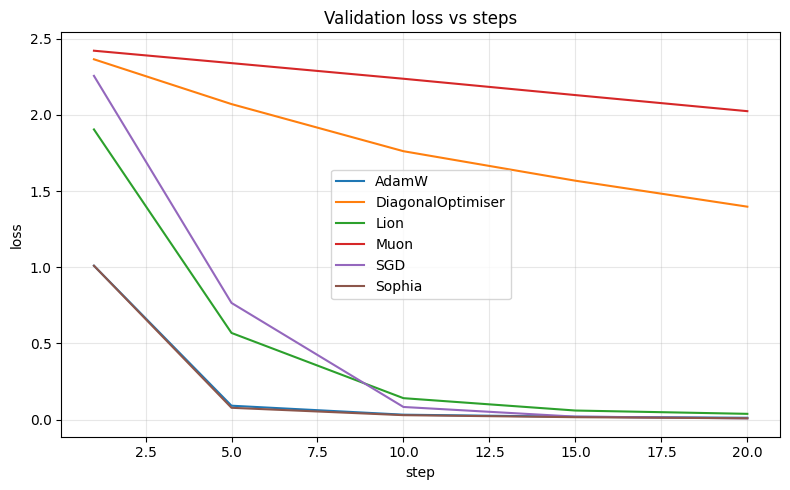

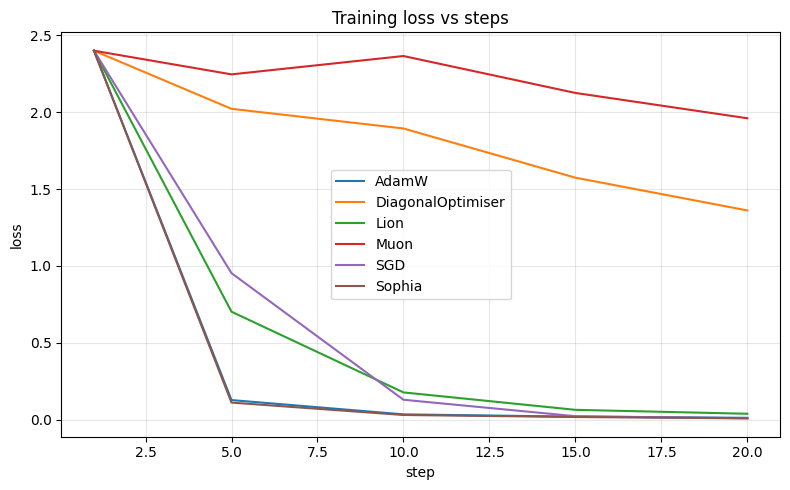

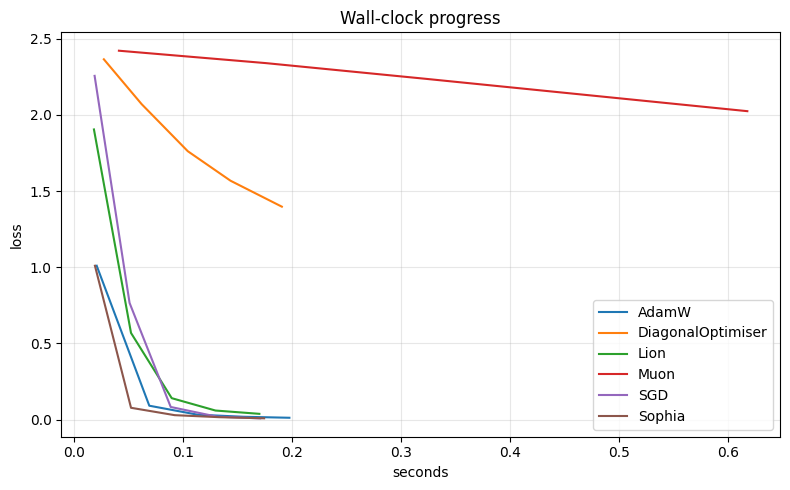

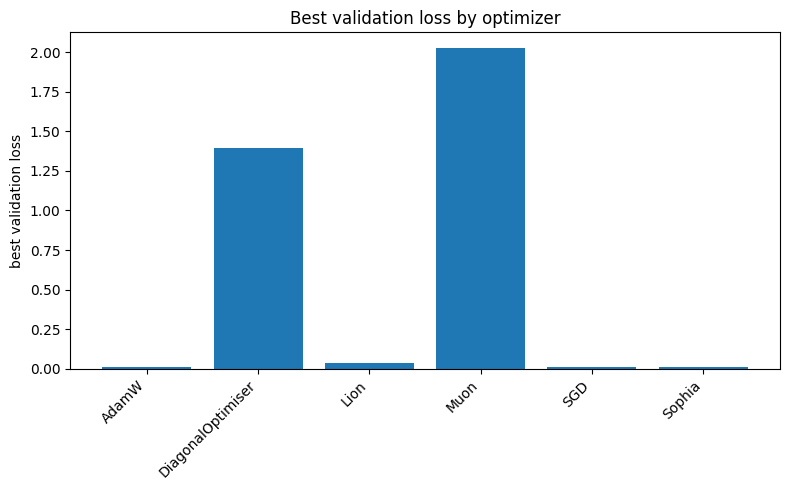

In [19]:
plot_dir.mkdir(parents=True, exist_ok=True)

if pd is not None:
    for y_key, title, filename in [
        ("val_loss", "Validation loss vs steps", "val_loss_vs_steps.png"),
        ("train_loss", "Training loss vs steps", "train_loss_vs_steps.png"),
        ("wall_time_sec", "Wall-clock progress", "wall_clock_progress.png"),
    ]:
        plt.figure(figsize=(8, 5))
        for opt_name, group in metrics_df.groupby("optimizer"):
            group = group.sort_values("step")
            x = group["step"] if y_key != "wall_time_sec" else group["wall_time_sec"]
            y = group["val_loss"] if y_key == "wall_time_sec" else group[y_key]
            plt.plot(x, y, label=opt_name)
        plt.title(title)
        plt.xlabel("step" if y_key != "wall_time_sec" else "seconds")
        plt.ylabel("loss")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(plot_dir / filename, dpi=180)
        plt.show()

    plt.figure(figsize=(8, 5))
    plt.bar(aggregate_df["optimizer"], aggregate_df["best_val_loss_mean"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("best validation loss")
    plt.title("Best validation loss by optimizer")
    plt.tight_layout()
    plt.savefig(plot_dir / "best_val_loss_bar.png", dpi=180)
    plt.show()
else:
    print("Install pandas to generate plots.")

## Interpretation Notes

The synthetic image dataset is only a smoke fallback. For publication-quality neural training evidence, set `SMOKE=False`, install torchvision, and use MNIST or FashionMNIST.

Do not claim DiagonalOptimiser is faster unless optimizer step timing includes curvature refreshes and HVP probes.